In [25]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_core.messages.utils import trim_messages, count_tokens_approximately
from langchain_openai import ChatOpenAI
import os

In [26]:
load_dotenv()



api_key = os.getenv("GROQ_API_KEY")

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)

In [27]:
MAX_TOKEN = 150

In [28]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state['messages'],
        strategy = 'last',
        token_counter = count_tokens_approximately,
        max_tokens = MAX_TOKEN
    )

    print("Current Token Count : " ,  count_tokens_approximately(messages = messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {"messages": [response]}

In [29]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [30]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

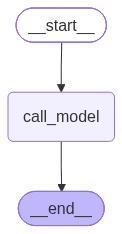

In [31]:

graph

In [32]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Rana."}]},
    config,
)

result["messages"][-1].content

Current Token Count :  9
Hi, my name is Rana.


'Hello Rana! 👋 Nice to meet you. How can I assist you today?'

In [33]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count :  39
Hi, my name is Rana.
Hello Rana! 👋 Nice to meet you. How can I assist you today?
I am learning LangGraph.


'That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM workflows, and there’s a lot you can do with it. How can I help you get started?\n\nHere are a few ways I can assist:\n\n| Topic | What I can cover |\n|-------|-------------------|\n| **Core concepts** | Nodes, edges, state, callbacks, and the execution model. |\n| **Installation & setup** | Quick‑start scripts, environment configuration, and common pitfalls. |\n| **Building your first graph** | Step‑by‑step walkthrough of a simple “question‑answer” or “tool‑use” graph. |\n| **Advanced patterns** | Conditional branching, loops, memory management, streaming responses, and integrating external APIs. |\n| **Debugging & monitoring** | Using the built‑in logger, visualizing graphs, and troubleshooting common errors. |\n| **Resources & community** | Official docs, tutorials, example repos, and where to ask questions. |\n\nLet me know which area you’d like to dive into (or if you have a specific problem

In [34]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count :  13
Can you explain short term memory?


'**Short‑term memory (STM)** is a mental system that temporarily holds a limited amount of information for a brief period—typically on the order of seconds to a few minutes. It’s the “scratch‑pad” of the mind, letting you keep something in mind long enough to use it (e.g., remembering a phone number while you dial it).\n\nBelow is a concise overview that covers the main features, underlying mechanisms, and how STM fits into the broader memory landscape.\n\n---\n\n## 1. Core Characteristics\n\n| Feature | Typical Value | What it Means |\n|---------|----------------|----------------|\n| **Capacity** | 5–9 items (Miller’s “7\u202f±\u202f2”) | You can actively maintain roughly 7 discrete chunks (e.g., digits, words, objects). “Chunking”—grouping items into meaningful units—can boost effective capacity. |\n| **Duration** | ~15–30\u202fseconds without rehearsal | If you don’t rehearse or refresh the information, it fades quickly. Some studies suggest a decay to near‑zero after ~45\u202fsecon

In [36]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count :  8
What is my name?


'I don’t have any information about your name. If you’d like me to address you by name, just let me know what it is!'

In [35]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Rana.
------------------------------------------------------------------------------------------------------------------------
Hello Rana! 👋 Nice to meet you. How can I assist you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That’s great! LangGraph is a powerful framework for building composable, state‑driven LLM workflows, and there’s a lot you can do with it. How can I help you get started?

Here are a few ways I can assist:

| Topic | What I can cover |
|-------|-------------------|
| **Core concepts** | Nodes, edges, state, callbacks, and the execution model. |
| **Installation & setup** | Quick‑start scripts, environment configuration, and common pitfalls. |
| **Building your first graph** | Step‑by‑step walkthrough of a simple “question‑ans